## 분류 (Classification) 모델

<img src="https://velog.velcdn.com/images/newnew_daddy/post/09b3dfe6-03d8-460e-a593-692a036f60aa/image.png" width="50%">

#### 1. 개념
- 분류 모델은 주어진 입력 데이터에 대해 미리 정의된 클래스(레이블) 중 하나로 분류하는 모델
- 주어진 데이터를 바탕으로 새로운 데이터가 어떤 클래스에 속하는지 예측

#### 2. 주요 모델
1. **로지스틱 회귀 (Logistic Regression)**
2. **k-최근접 이웃 (k-Nearest Neighbors, k-NN)**
3. **서포트 벡터 머신 (Support Vector Machine, SVM)**
4. **나이브 베이즈 (Naive Bayes)**
5. **결정 트리 (Decision Tree)**
6. **랜덤 포레스트 (Random Forest)**

## 로지스틱 회귀 (Logistic Regression)
- 이진 분류 문제를 해결하기 위해 사용되는 통계적 모델
- 회귀 모델이지만 출력이 0~1 사이의 확률값을 가지므로 분류에 사용된다.
- 시그모이드 함수를 사용하여 확률값 출력

    $\sigma(x) = \frac{1}{1 + e^{-x}}$


### 1. 이중 분류 모델

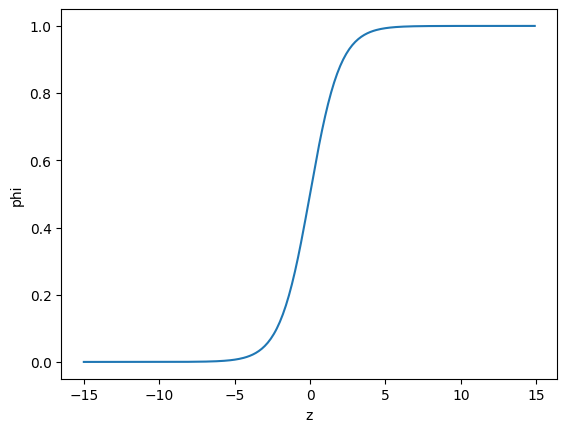

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

z = np.arange(-15, 15, 0.1)
phi = 1 / (1 + np.exp(-z))

plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

In [5]:
import pandas as pd

wine = pd.read_csv('dataset/wine.csv')
wine['class'].unique()

array([0., 1.])

In [6]:
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [3]:
wine.isnull().sum()

alcohol    0
sugar      0
pH         0
class      0
dtype: int64

In [23]:
X = wine[wine.columns[:-1]]
y = wine['class']

X.shape, y.shape

((6497, 3), (6497,))

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4547, 3), (1950, 3), (4547,), (1950,))

In [26]:
ss = StandardScaler()
train_scaled = ss.fit_transform(X_train)
test_scaled = ss.transform(X_test)

#### LogisticRegression 메소드의 주요 인자 설명

```python
from sklearn.linear_model import LogisticRegression

LogisticRegression(
    penalty='l2',           # 규제의 종류. 'l1', 'l2', 'elasticnet' 또는 'none' 중 선택 가능. 기본값은 'l2'.
    tol=0.001,              # 종료 기준. 최적화가 수렴하는 데 사용하는 허용 오차.
    C=1.0,                  # 규제 강도. 작은 값일수록 강한 규제를 의미.
    fit_intercept=True,     # 상수를 포함할지 여부. True일 경우 모델이 절편을 학습함.
    class_weight=None,      # 클래스 가중치. {class_label: weight} 형식의 dict 또는 'balanced'. 불균형 데이터셋에서 유용.
    random_state=None,      # 난수 시드 설정. 결과 재현성을 위해 사용.
    max_iter=100,           # 최적화 알고리즘의 최대 반복 횟수.
    multi_class='auto',     # 다중 클래스 문제에서 'ovr'(one-vs-rest), 'multinomial'(softmax) 방식 또는 'auto' 사용.
    verbose=0,              # 상세 출력을 원할 경우 설정. 0은 출력하지 않음을 의미.
    n_jobs=None             # 작업에 사용할 CPU 코어 수. -1이면 모든 코어 사용.
)
```

In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
## predict() : 예측 결과값
test_pred = lr.predict(test_scaled)

## predict_proba() : 예측 확률을 반환
test_proba = lr.predict_proba(test_scaled)

test_pred.shape

(1950,)

In [30]:
print(lr.score(train_scaled, y_train))
print(lr.score(test_scaled, y_test))

0.7842533538596878
0.7712820512820513


In [31]:
print(lr.classes_)
print(lr.coef_, lr.intercept_)

[0. 1.]
[[ 0.53657472  1.67751443 -0.70318861]] [1.82826977]


### 2. 다중 분류 모델

In [32]:
import pandas as pd

fish = pd.read_csv('dataset/fish.csv')

fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [33]:
fish_input = fish[['Weight','Length','Diagonal','Height','Width']].values

fish_target = fish['Species'].values

fish_input.shape, fish_target.shape

((159, 5), (159,))

In [34]:
set(fish_target)

{'Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'}

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    fish_input, fish_target, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((111, 5), (48, 5), (111,), (48,))

In [36]:
ss = StandardScaler()
train_scaled = ss.fit_transform(X_train)
test_scaled = ss.transform(X_test)

In [37]:
lr = LogisticRegression(C=20, max_iter=100)

## 모델의 fit 메소드의 y값에는 (1,) 형태의 데이터가 들어가는 것이 적절하다.
lr.fit(train_scaled, y_train)

print(lr.score(train_scaled, y_train))
print(lr.score(test_scaled, y_test))

0.9279279279279279
0.9375


In [38]:
print(lr.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [39]:
# predict_proba -> 각 row 값들에 대해 해당 class 로 예측되는 확률

proba = lr.predict_proba(test_scaled)
print(np.round(proba, decimals=3))

[[0.    0.014 0.834 0.    0.141 0.008 0.003]
 [0.    0.003 0.053 0.    0.006 0.938 0.   ]
 [0.    0.    0.038 0.929 0.013 0.02  0.   ]
 [0.01  0.034 0.327 0.006 0.547 0.    0.076]
 [0.    0.    0.894 0.003 0.098 0.003 0.002]
 [0.999 0.    0.    0.    0.    0.    0.   ]
 [0.    0.001 0.058 0.    0.003 0.937 0.   ]
 [0.001 0.008 0.325 0.014 0.632 0.001 0.019]
 [0.    0.002 0.779 0.002 0.204 0.    0.012]
 [0.    0.    0.023 0.977 0.    0.    0.   ]
 [0.983 0.003 0.    0.    0.001 0.    0.013]
 [0.042 0.    0.837 0.008 0.001 0.    0.113]
 [0.992 0.005 0.    0.    0.    0.    0.003]
 [0.007 0.891 0.004 0.    0.088 0.    0.011]
 [0.999 0.001 0.    0.    0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.    0.   ]
 [0.001 0.    0.931 0.    0.    0.    0.068]
 [0.    0.003 0.778 0.009 0.196 0.    0.014]
 [0.001 0.034 0.7   0.004 0.239 0.001 0.021]
 [0.991 0.006 0.    0.    0.    0.    0.003]
 [0.    0.002 0.057 0.    0.007 0.935 0.   ]
 [0.997 0.002 0.    0.    0.    0.    0.   ]
 [0.984 0.

In [40]:
# [lr.classes_[int(np.argmax(i))] for i in proba] 와 동일

test_pred = lr.predict(test_scaled)